# Análise Estatística em Escala: AUs vs Blendshapes
Comparação com todos os ~300 participantes e ~1132 vídeos (excluídos os excluded_ids)

In [1]:
# CÉLULA 1: Imports e configuração
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.ndimage import uniform_filter1d
import warnings
warnings.filterwarnings('ignore')

#DIRECTORY_VARIABLES NEED TO CHANGE TO YOUR CORRECT DIRECTORIES
BASE_DIR = r'\ABAW\data'

AU_DIR = os.path.join(BASE_DIR, 'au_features')
BS_DIR = os.path.join(BASE_DIR, 'blendshape_features')
SPLIT_DIR = os.path.join(BASE_DIR, 'split')

EXCLUDED_IDS = set(str(x) for x in [
    82723, 82687, 82569, 82570, 82576, 82577, 82581, 82587, 82589,
    82624, 82627, 82628, 82642, 82652, 82664, 82665, 82674, 82677,
    82681, 82690, 82705, 82708, 82709, 82738, 82758, 82768,
    82777, 82783, 82784, 82794, 82807, 82812, 82813, 82814,
    82815, 82817, 82819, 82820, 82832, 82845, 82861, 82866,
    82875, 82879, 82895, 82899, 82910, 82912, 82919, 82555,
    82786, 82827, 82927, 82928, 82956, 82968, 83008, 83011,
    83045, 83080, 83086
])

EFFECTIVE_FPS = 10.0
WINDOW_SIZE = 30   # ~3s
WINDOW_STEP = 10   # ~1s

AU_NAMES = [
    'AU01', 'AU02', 'AU04', 'AU05', 'AU06', 'AU07', 'AU09', 'AU10',
    'AU11', 'AU12', 'AU14', 'AU15', 'AU17', 'AU20', 'AU23', 'AU24',
    'AU25', 'AU26', 'AU28', 'AU43'
]

BS_NAMES = [
    '_neutral', 'browDownLeft', 'browDownRight', 'browInnerUp', 'browOuterUpLeft',
    'browOuterUpRight', 'cheekPuff', 'cheekSquintLeft', 'cheekSquintRight',
    'eyeBlinkLeft', 'eyeBlinkRight', 'eyeLookDownLeft', 'eyeLookDownRight',
    'eyeLookInLeft', 'eyeLookInRight', 'eyeLookOutLeft', 'eyeLookOutRight',
    'eyeLookUpLeft', 'eyeLookUpRight', 'eyeSquintLeft', 'eyeSquintRight',
    'eyeWideLeft', 'eyeWideRight', 'jawForward', 'jawLeft', 'jawOpen',
    'jawRight', 'mouthClose', 'mouthDimpleLeft', 'mouthDimpleRight',
    'mouthFrownLeft', 'mouthFrownRight', 'mouthFunnel', 'mouthLeft',
    'mouthLowerDownLeft', 'mouthLowerDownRight', 'mouthPressLeft',
    'mouthPressRight', 'mouthPucker', 'mouthRight', 'mouthRollLower',
    'mouthRollUpper', 'mouthShrugLower', 'mouthShrugUpper', 'mouthSmileLeft',
    'mouthSmileRight', 'mouthStretchLeft', 'mouthStretchRight', 'mouthUpperUpLeft',
    'mouthUpperUpRight', 'noseSneerLeft', 'noseSneerRight'
]

print(f"AUs: {len(AU_NAMES)} | Blendshapes: {len(BS_NAMES)}")

AUs: 20 | Blendshapes: 52


In [2]:
# CÉLULA 2: Carregar TODOS os vídeos com AU + BS + label

def load_all_videos(split_file, au_dir, bs_dir, excluded_ids):
    videos = []
    missing = 0
    with open(split_file, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',', 2)
            if len(parts) < 2:
                continue
            
            video_path = parts[0]
            label = int(parts[1])
            path_parts = video_path.replace('\\', '/').split('/')
            pid = path_parts[1]
            video_name = path_parts[-1].replace('.mp4', '')
            
            if pid in excluded_ids:
                continue
            
            # Tentar achar os .npy (com ou sem .mp4 no nome)
            au_path = None
            for suffix in [f'{video_name}.mp4.npy', f'{video_name}.npy']:
                p = os.path.join(au_dir, pid, suffix)
                if os.path.exists(p):
                    au_path = p
                    break
            
            bs_path = None
            for suffix in [f'{video_name}.mp4.npy', f'{video_name}.npy']:
                p = os.path.join(bs_dir, pid, suffix)
                if os.path.exists(p):
                    bs_path = p
                    break
            
            if au_path is None or bs_path is None:
                missing += 1
                continue
            
            videos.append({
                'pid': pid, 'video_name': video_name,
                'au_path': au_path, 'bs_path': bs_path,
                'label': label
            })
    return videos, missing

all_videos = []
for split in ['train.txt', 'val.txt', 'test.txt']:
    vids, miss = load_all_videos(
        os.path.join(SPLIT_DIR, split), AU_DIR, BS_DIR, EXCLUDED_IDS)
    all_videos.extend(vids)
    print(f"{split}: {len(vids)} vídeos carregados, {miss} missing")

labels = [v['label'] for v in all_videos]
pids = set(v['pid'] for v in all_videos)
print(f"\nTotal: {len(all_videos)} vídeos | {len(pids)} participantes")
print(f"A/H: {sum(labels)} ({sum(labels)/len(labels)*100:.1f}%) | "
      f"Sem A/H: {len(labels)-sum(labels)} ({(len(labels)-sum(labels))/len(labels)*100:.1f}%)")

train.txt: 598 vídeos carregados, 0 missing
val.txt: 107 vídeos carregados, 0 missing
test.txt: 427 vídeos carregados, 0 missing

Total: 1132 vídeos | 239 participantes
A/H: 618 (54.6%) | Sem A/H: 514 (45.4%)


In [3]:
# CÉLULA 3: Extrair features estatísticas de cada vídeo
# Para cada vídeo: mean, std, zcr_slope por feature

def compute_video_stats(signal, window_size=30, window_step=10):
    """Calcula mean, std e zero-crossing rate do slope pra um sinal."""
    mean = np.mean(signal)
    std = np.std(signal)
    
    # ZCR do slope em janelas
    if len(signal) > window_size:
        slopes = []
        for start in range(0, len(signal) - window_size + 1, window_step):
            window = signal[start:start + window_size]
            x = np.arange(window_size)
            slopes.append(np.polyfit(x, window, 1)[0])
        slopes = np.array(slopes)
        if len(slopes) > 1:
            zcr = np.sum(np.abs(np.diff(np.sign(slopes))) > 0) / len(slopes)
        else:
            zcr = 0.0
    else:
        zcr = 0.0
    
    return mean, std, zcr


# Calcular pra todos os vídeos
from tqdm.notebook import tqdm

results = []  # lista de dicts com todas as stats

for v in tqdm(all_videos, desc="Calculando stats"):
    au = np.load(v['au_path']).astype(np.float64)
    au = np.nan_to_num(au, nan=0.0)
    bs = np.load(v['bs_path']).astype(np.float64)
    
    min_len = min(len(au), len(bs))
    au = au[:min_len]
    bs = bs[:min_len]
    
    row = {'pid': v['pid'], 'label': v['label'], 'n_frames': min_len}
    
    # AUs
    for i, name in enumerate(AU_NAMES):
        m, s, z = compute_video_stats(au[:, i])
        row[f'au_{name}_mean'] = m
        row[f'au_{name}_std'] = s
        row[f'au_{name}_zcr'] = z
    
    # Blendshapes
    for i, name in enumerate(BS_NAMES):
        m, s, z = compute_video_stats(bs[:, i])
        row[f'bs_{name}_mean'] = m
        row[f'bs_{name}_std'] = s
        row[f'bs_{name}_zcr'] = z
    
    results.append(row)

stats_df = pd.DataFrame(results)
print(f"DataFrame: {stats_df.shape}")
print(f"Colunas de features: {stats_df.shape[1] - 3} (excluindo pid, label, n_frames)")

Calculando stats:   0%|          | 0/1132 [00:00<?, ?it/s]

DataFrame: (1132, 219)
Colunas de features: 216 (excluindo pid, label, n_frames)


In [4]:
# CÉLULA 4: Teste estatístico — quais features diferem significativamente entre A/H e sem A/H?
# Mann-Whitney U (não assume normalidade)

ah_df = stats_df[stats_df['label'] == 1]
no_ah_df = stats_df[stats_df['label'] == 0]

print(f"Vídeos A/H: {len(ah_df)} | Sem A/H: {len(no_ah_df)}")
print(f"\n{'Feature':<35} {'Métrica':<6} {'A/H mean':>10} {'NoAH mean':>10} "
      f"{'Diff':>8} {'p-value':>10} {'Sig':>5} {'Effect (r)':>10}")
print("=" * 105)

significant_features = []
all_test_results = []

feature_cols = [c for c in stats_df.columns if c not in ['pid', 'label', 'n_frames']]

for col in sorted(feature_cols):
    vals_ah = ah_df[col].values
    vals_no = no_ah_df[col].values
    
    # Mann-Whitney U test
    u_stat, p_val = stats.mannwhitneyu(vals_ah, vals_no, alternative='two-sided')
    
    # Effect size (rank-biserial r)
    n1, n2 = len(vals_ah), len(vals_no)
    r = 1 - (2 * u_stat) / (n1 * n2)
    
    mean_ah = np.mean(vals_ah)
    mean_no = np.mean(vals_no)
    diff = mean_ah - mean_no
    
    # Significância com correção de Bonferroni
    bonferroni_alpha = 0.05 / len(feature_cols)
    sig = '***' if p_val < bonferroni_alpha else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
    
    all_test_results.append({
        'feature': col, 'mean_ah': mean_ah, 'mean_no': mean_no,
        'diff': diff, 'p_value': p_val, 'effect_r': r, 'sig': sig
    })
    
    if p_val < 0.05:
        significant_features.append(col)

# Ordenar por effect size absoluto
test_df = pd.DataFrame(all_test_results)
test_df['abs_r'] = test_df['effect_r'].abs()
test_df = test_df.sort_values('abs_r', ascending=False)

# Mostrar top 30
for _, row in test_df.head(30).iterrows():
    parts = row['feature'].rsplit('_', 1)
    feat_name = parts[0]
    metric = parts[1] if len(parts) > 1 else ''
    print(f"{feat_name:<35} {metric:<6} {row['mean_ah']:>10.4f} {row['mean_no']:>10.4f} "
          f"{row['diff']:>+8.4f} {row['p_value']:>10.2e} {row['sig']:>5} {row['effect_r']:>+10.4f}")

print(f"\nTotal features significativas (p<0.05): {len(significant_features)}/{len(feature_cols)}")
print(f"Significativas após Bonferroni: {len(test_df[test_df['sig']=='***'])}")

Vídeos A/H: 618 | Sem A/H: 514

Feature                             Métrica   A/H mean  NoAH mean     Diff    p-value   Sig Effect (r)
bs_browDownLeft                     std        0.0379     0.0248  +0.0131   2.14e-08   ***    -0.1931
au_AU06                             std        0.0764     0.0587  +0.0177   6.44e-08   ***    -0.1864
au_AU09                             std        0.0947     0.0842  +0.0105   7.52e-08   ***    -0.1855
bs_browDownRight                    std        0.0356     0.0244  +0.0111   1.19e-07   ***    -0.1826
au_AU06                             mean       0.1409     0.1209  +0.0200   5.49e-07   ***    -0.1727
au_AU12                             std        0.0893     0.0680  +0.0213   6.44e-07   ***    -0.1716
au_AU26                             zcr        0.4207     0.3836  +0.0371   1.13e-06   ***    -0.1677
bs_eyeLookOutRight                  std        0.0840     0.0704  +0.0136   1.86e-06   ***    -0.1644
bs_mouthSmileLeft                   std        0.

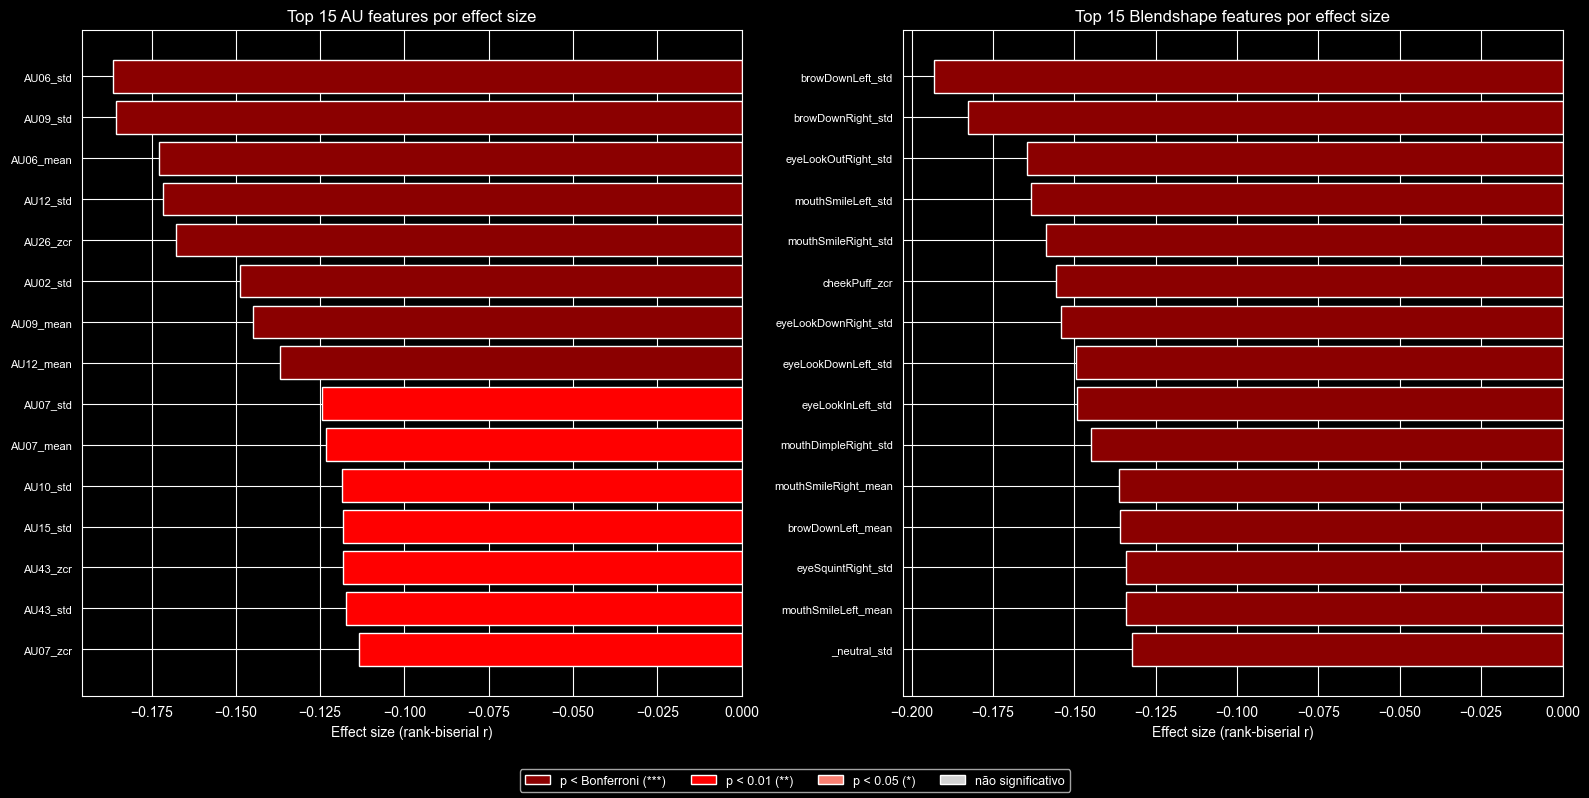

In [5]:
# CÉLULA 5: Visualizar top features — AU vs BS

# Separar AU e BS results
au_results = test_df[test_df['feature'].str.startswith('au_')].head(15)
bs_results = test_df[test_df['feature'].str.startswith('bs_')].head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# AUs
ax = axes[0]
colors = ['darkred' if r['sig'] == '***' else ('red' if r['sig'] == '**' else 
          ('salmon' if r['sig'] == '*' else 'lightgray')) 
          for _, r in au_results.iterrows()]
ax.barh(range(len(au_results)), au_results['effect_r'].values, color=colors)
ax.set_yticks(range(len(au_results)))
ax.set_yticklabels([r['feature'].replace('au_', '') for _, r in au_results.iterrows()], fontsize=8)
ax.set_xlabel('Effect size (rank-biserial r)')
ax.set_title('Top 15 AU features por effect size')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()

# Blendshapes
ax = axes[1]
colors = ['darkred' if r['sig'] == '***' else ('red' if r['sig'] == '**' else 
          ('salmon' if r['sig'] == '*' else 'lightgray')) 
          for _, r in bs_results.iterrows()]
ax.barh(range(len(bs_results)), bs_results['effect_r'].values, color=colors)
ax.set_yticks(range(len(bs_results)))
ax.set_yticklabels([r['feature'].replace('bs_', '') for _, r in bs_results.iterrows()], fontsize=8)
ax.set_xlabel('Effect size (rank-biserial r)')
ax.set_title('Top 15 Blendshape features por effect size')
ax.axvline(0, color='black', linewidth=0.5)
ax.invert_yaxis()

# Legenda de cores
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkred', label='p < Bonferroni (***)')  ,
    Patch(facecolor='red', label='p < 0.01 (**)'),
    Patch(facecolor='salmon', label='p < 0.05 (*)'),
    Patch(facecolor='lightgray', label='não significativo')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=9)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

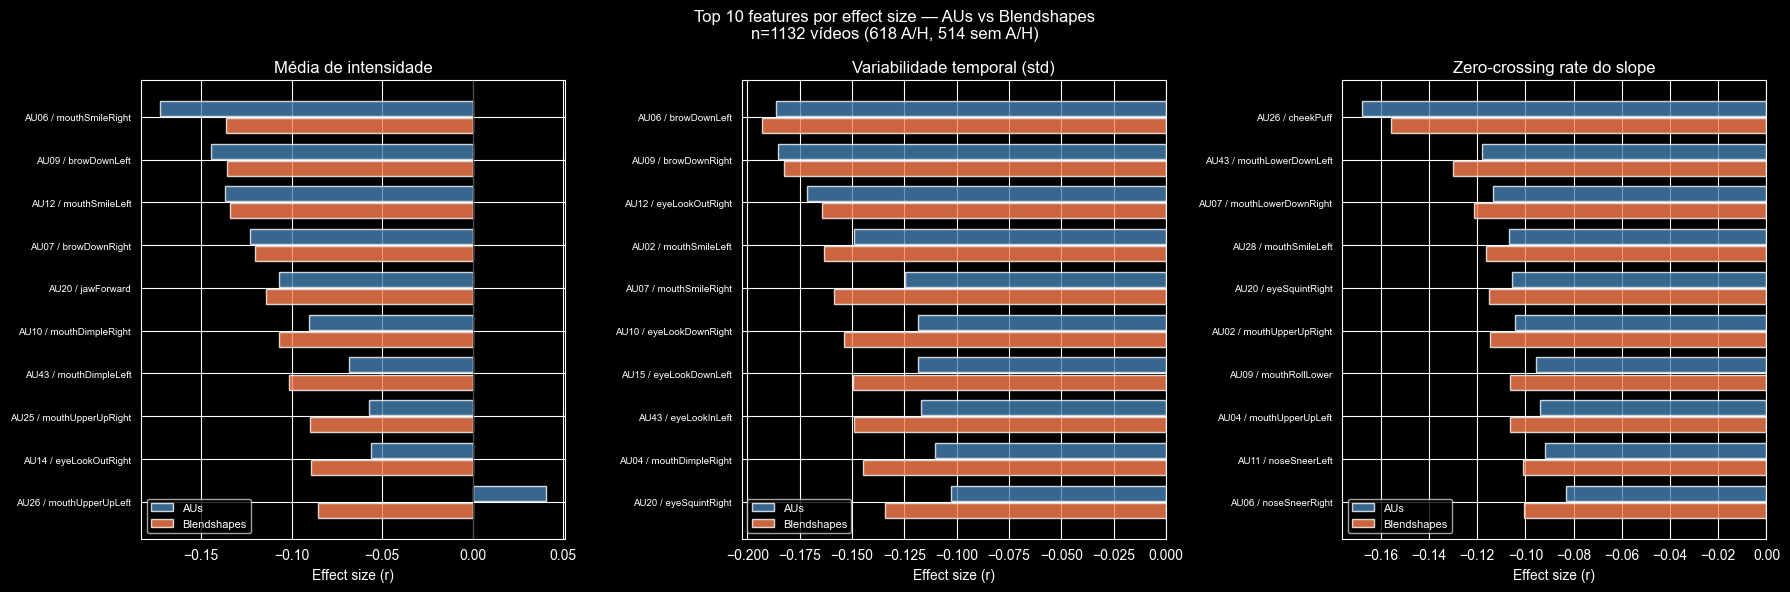

In [6]:
# CÉLULA 6: Comparação direta — mean vs std vs zcr por tipo de feature

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, metric, title in [
    (axes[0], 'mean', 'Média de intensidade'),
    (axes[1], 'std', 'Variabilidade temporal (std)'),
    (axes[2], 'zcr', 'Zero-crossing rate do slope')
]:
    # Filtrar features dessa métrica
    metric_df = test_df[test_df['feature'].str.endswith(f'_{metric}')].copy()
    metric_df['source'] = metric_df['feature'].apply(
        lambda x: 'AU' if x.startswith('au_') else 'BS')
    
    au_subset = metric_df[metric_df['source'] == 'AU'].sort_values('abs_r', ascending=False).head(10)
    bs_subset = metric_df[metric_df['source'] == 'BS'].sort_values('abs_r', ascending=False).head(10)
    
    # Plot lado a lado
    y_pos = np.arange(10)
    
    if len(au_subset) >= 10 and len(bs_subset) >= 10:
        ax.barh(y_pos - 0.2, au_subset['effect_r'].values, 0.35, 
                color='steelblue', alpha=0.8, label='AUs')
        ax.barh(y_pos + 0.2, bs_subset['effect_r'].values, 0.35,
                color='coral', alpha=0.8, label='Blendshapes')
        
        # Labels combinados
        combined_labels = []
        for (_, au_row), (_, bs_row) in zip(au_subset.iterrows(), bs_subset.iterrows()):
            au_name = au_row['feature'].replace('au_', '').replace(f'_{metric}', '')
            bs_name = bs_row['feature'].replace('bs_', '').replace(f'_{metric}', '')
            combined_labels.append(f"{au_name} / {bs_name}")
        
        ax.set_yticks(y_pos)
        ax.set_yticklabels(combined_labels, fontsize=7)
    
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlabel('Effect size (r)')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.suptitle(f'Top 10 features por effect size — AUs vs Blendshapes\n'
             f'n={len(all_videos)} vídeos ({len(ah_df)} A/H, {len(no_ah_df)} sem A/H)',
             fontsize=12)
plt.tight_layout()
plt.show()

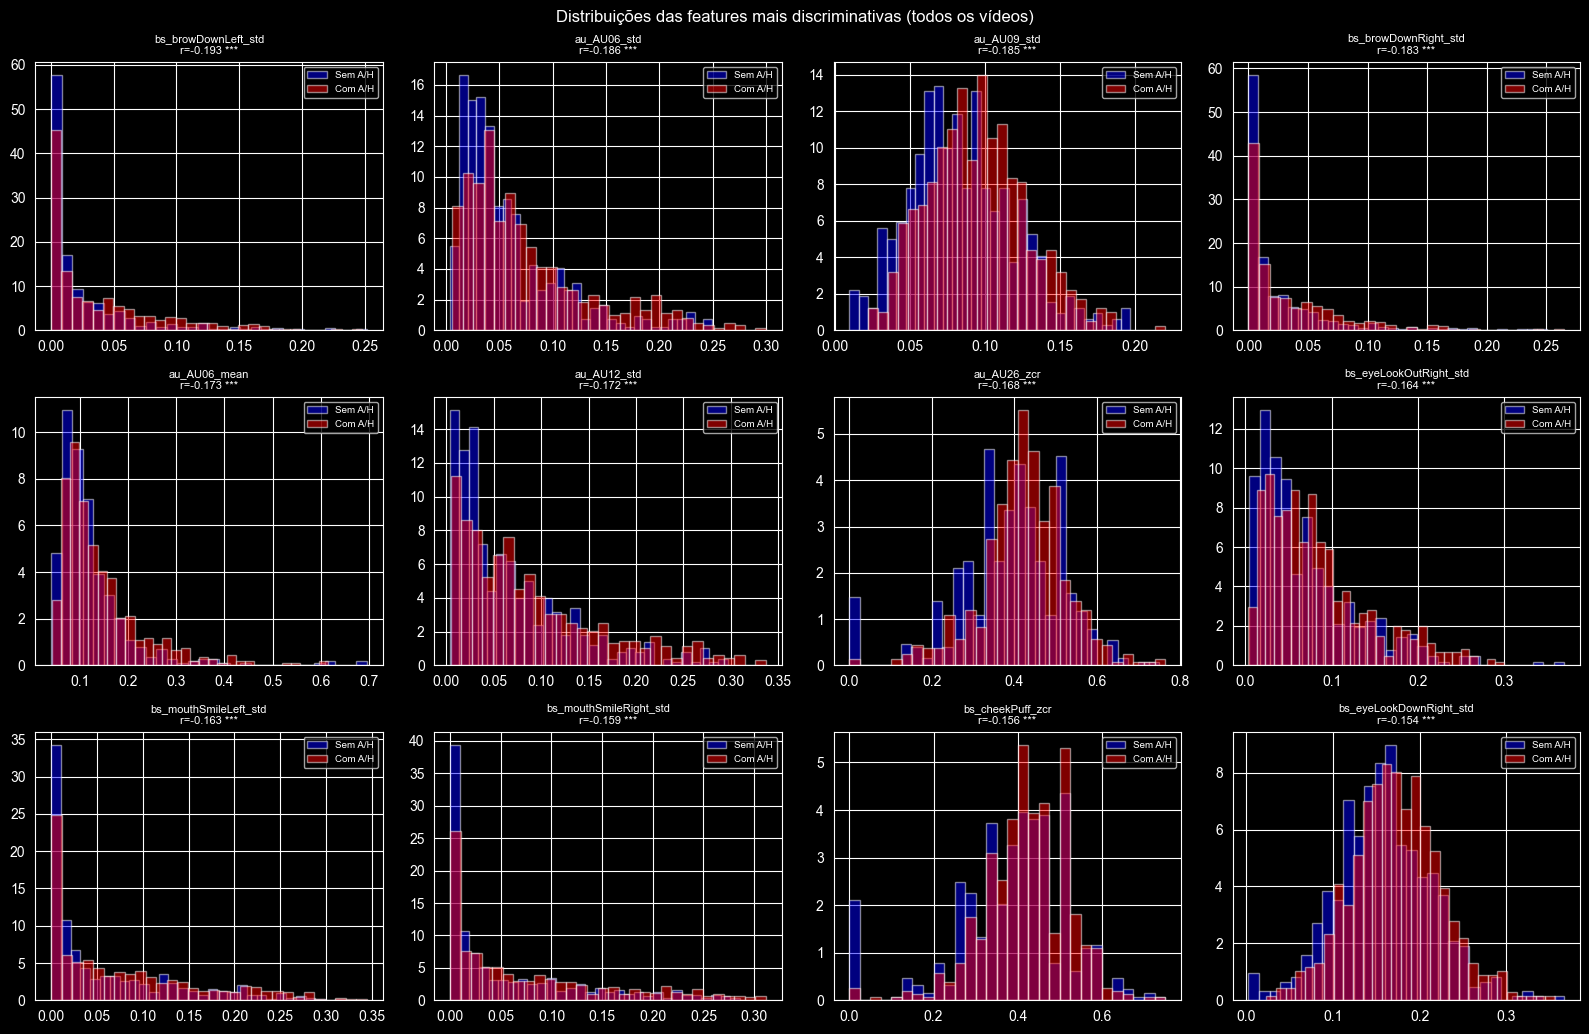

In [7]:
# CÉLULA 7: Distribuições das features mais discriminativas

top_features = test_df[test_df['sig'].isin(['***', '**'])].head(12)['feature'].tolist()

if len(top_features) == 0:
    top_features = test_df.head(12)['feature'].tolist()

n_cols = 4
n_rows = (len(top_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3.5 * n_rows))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    ax = axes[i]
    vals_ah = ah_df[feat].values
    vals_no = no_ah_df[feat].values
    
    ax.hist(vals_no, bins=30, alpha=0.5, color='blue', label='Sem A/H', density=True)
    ax.hist(vals_ah, bins=30, alpha=0.5, color='red', label='Com A/H', density=True)
    
    # Info
    row = test_df[test_df['feature'] == feat].iloc[0]
    ax.set_title(f"{feat}\nr={row['effect_r']:.3f} {row['sig']}", fontsize=8)
    ax.legend(fontsize=7)

# Esconder axes extras
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuições das features mais discriminativas (todos os vídeos)', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
# CÉLULA 8: Resumo final — AU vs BS

print("=" * 70)
print("RESUMO: QUAL REPRESENTAÇÃO DISCRIMINA MELHOR A/H?")
print(f"Dataset: {len(all_videos)} vídeos, {len(pids)} participantes")
print("=" * 70)

for source, prefix in [('AUs (Py-Feat)', 'au_'), ('Blendshapes (MediaPipe)', 'bs_')]:
    subset = test_df[test_df['feature'].str.startswith(prefix)]
    n_sig_05 = len(subset[subset['sig'] != ''])
    n_sig_bonf = len(subset[subset['sig'] == '***'])
    max_r = subset['abs_r'].max()
    mean_r = subset['abs_r'].mean()
    
    # Por métrica
    for metric in ['mean', 'std', 'zcr']:
        m_subset = subset[subset['feature'].str.endswith(f'_{metric}')]
        m_sig = len(m_subset[m_subset['sig'] != ''])
        m_max_r = m_subset['abs_r'].max() if len(m_subset) > 0 else 0
        print(f"  {source} — {metric}: {m_sig} significativas, max |r|={m_max_r:.4f}")
    
    print(f"  TOTAL {source}: {n_sig_05} sig (p<0.05), {n_sig_bonf} sig (Bonferroni), "
          f"max |r|={max_r:.4f}, mean |r|={mean_r:.4f}")
    print()

print("\nInterpretação do effect size (r):")
print("  |r| < 0.1: negligível")
print("  |r| 0.1-0.3: pequeno")
print("  |r| 0.3-0.5: médio")
print("  |r| > 0.5: grande")

RESUMO: QUAL REPRESENTAÇÃO DISCRIMINA MELHOR A/H?
Dataset: 1132 vídeos, 239 participantes
  AUs (Py-Feat) — mean: 7 significativas, max |r|=0.1727
  AUs (Py-Feat) — std: 15 significativas, max |r|=0.1864
  AUs (Py-Feat) — zcr: 15 significativas, max |r|=0.1677
  TOTAL AUs (Py-Feat): 37 sig (p<0.05), 8 sig (Bonferroni), max |r|=0.1864, mean |r|=0.0787

  Blendshapes (MediaPipe) — mean: 18 significativas, max |r|=0.1363
  Blendshapes (MediaPipe) — std: 38 significativas, max |r|=0.1931
  Blendshapes (MediaPipe) — zcr: 26 significativas, max |r|=0.1556
  TOTAL Blendshapes (MediaPipe): 82 sig (p<0.05), 19 sig (Bonferroni), max |r|=0.1931, mean |r|=0.0742


Interpretação do effect size (r):
  |r| < 0.1: negligível
  |r| 0.1-0.3: pequeno
  |r| 0.3-0.5: médio
  |r| > 0.5: grande
